In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf

X_test = np.load('../data/processed/X_test.npy')
y_test = np.load('../data/processed/y_test.npy')
y_train = np.load('../data/processed/y_train.npy')

y_scaler = MinMaxScaler()
y_scaler.fit(y_train)

print("Data loaded")

Data loaded


In [2]:
import tensorflow as tf
from tensorflow.keras.models import load_model

model = load_model('../outputs/models/lstm_soh.keras')
print("Model loaded")

Model loaded


In [3]:
import scipy.io

def extract_soh(cycles):
    discharge_capacities = []
    for i in range(cycles.shape[0]):
        cycle = cycles[i]
        if cycle['type'][0] == 'discharge':
            current = cycle['data'][0]['Current_measured'][0][0]
            time = cycle['data'][0]['Time'][0][0]
            capacity = np.trapezoid(abs(current), time) / 3600
            discharge_capacities.append(capacity)
    initial = discharge_capacities[0]
    soh = [cap / initial * 100 for cap in discharge_capacities]
    return np.array(soh)

data_b0018 = scipy.io.loadmat('../data/raw/B0018.mat')
cycles_b0018 = data_b0018['B0018']['cycle'][0][0][0]
soh_b0018 = extract_soh(cycles_b0018)

print(f"B0018 SOH range: {soh_b0018.min():.2f}% to {soh_b0018.max():.2f}%")
print(f"Total discharge cycles: {len(soh_b0018)}")

B0018 SOH range: 72.82% to 100.00%
Total discharge cycles: 132


In [4]:
def create_sequences(soh, look_back=10):
    X, y = [], []
    for i in range(len(soh) - look_back):
        X.append(soh[i : i + look_back])
        y.append(soh[i + look_back])
    return np.array(X), np.array(y)

X_b0018, y_b0018 = create_sequences(soh_b0018)

from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
scaler.fit(X_b0018)
X_b0018_scaled = scaler.transform(X_b0018)
X_b0018_lstm = X_b0018_scaled.reshape(X_b0018_scaled.shape[0], X_b0018_scaled.shape[1], 1)

y_pred_scaled = model.predict(X_b0018_lstm)

y_scaler2 = MinMaxScaler()
y_scaler2.fit(y_b0018.reshape(-1, 1))
y_pred_real = y_scaler2.inverse_transform(y_pred_scaled)
y_actual_real = y_b0018

print(f"Actual SOH range: {y_actual_real.min():.2f}% to {y_actual_real.max():.2f}%")
print(f"Predicted SOH range: {y_pred_real.min():.2f}% to {y_pred_real.max():.2f}%")

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 130ms/step
Actual SOH range: 72.82% to 97.75%
Predicted SOH range: 74.78% to 97.00%


RUL at cycle 0  — Actual: 66, Predicted: 71
RUL at cycle 50 — Actual: 16, Predicted: 21
RUL at cycle 80 — Actual: 0, Predicted: 0


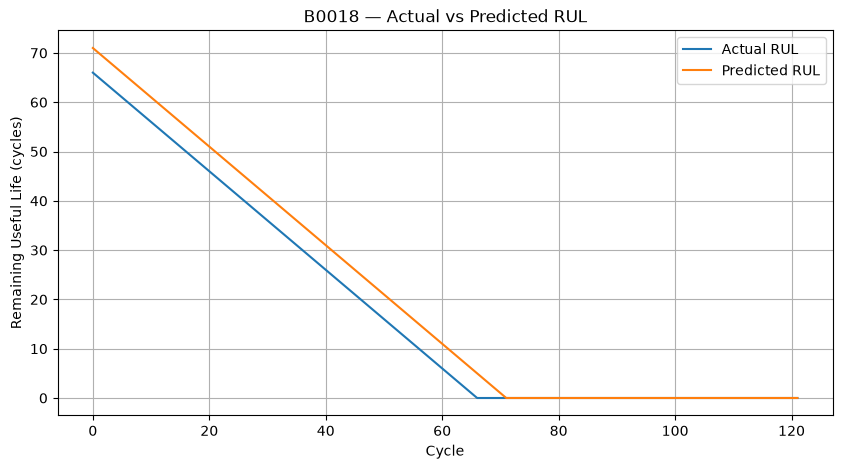

In [5]:
EOL_THRESHOLD = 80

def calculate_rul(soh_curve, threshold=EOL_THRESHOLD):
    rul = []
    n = len(soh_curve)
    for i in range(n):
        future = soh_curve[i:]
        below = np.where(future < threshold)[0]
        if len(below) == 0:
            rul.append(n - i)
        else:
            rul.append(below[0])
    return np.array(rul)

rul_actual = calculate_rul(y_actual_real.flatten())
rul_predicted = calculate_rul(y_pred_real.flatten())

print(f"RUL at cycle 0  — Actual: {rul_actual[0]}, Predicted: {rul_predicted[0]}")
print(f"RUL at cycle 50 — Actual: {rul_actual[50]}, Predicted: {rul_predicted[50]}")
print(f"RUL at cycle 80 — Actual: {rul_actual[80]}, Predicted: {rul_predicted[80]}")

plt.figure(figsize=(10, 5))
plt.plot(rul_actual, label='Actual RUL')
plt.plot(rul_predicted, label='Predicted RUL')
plt.xlabel('Cycle')
plt.ylabel('Remaining Useful Life (cycles)')
plt.title('B0018 — Actual vs Predicted RUL')
plt.legend()
plt.grid(True)
plt.show()

In [6]:
mae_rul = mean_absolute_error(rul_actual, rul_predicted)
rmse_rul = np.sqrt(mean_squared_error(rul_actual, rul_predicted))

print(f"RUL MAE:  {mae_rul:.2f} cycles")
print(f"RUL RMSE: {rmse_rul:.2f} cycles")

RUL MAE:  2.83 cycles
RUL RMSE: 3.74 cycles
